In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

### load dataset 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("heart_disease_uci.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### load dataset 2

In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

#load full data
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

### making subset of dataet 2

In [6]:
# First 12,000 training images and 2,000 test images
x_train = x_train_full[:12000]
y_train = y_train_full[:12000]

x_test = x_test_full[:2000]
y_test = y_test_full[:2000]

#Preprocessing for CNN 
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshaping to add the 'channel' dimension (28x28 grayscale -> 28x28x1)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print(f"Subset Training shape: {x_train.shape}") 
print(f"Subset Testing shape: {x_test.shape}")   

Subset Training shape: (12000, 28, 28, 1)
Subset Testing shape: (2000, 28, 28, 1)


## Required preprocessing (Heart Disease - Cleveland subset)
we first extract the Cleveland records so the dataset matches the required shape (303 x 14).

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

### Load CSV and keep Cleveland + required 14 columns

In [ ]:
raw = pd.read_csv("heart_disease_uci.csv")

cols_14 = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalch", "exang", "oldpeak", "slope", "ca", "thal", "num"
]


heart = raw[raw["dataset"].str.lower() == "cleveland"][cols_14].copy()
heart = heart.rename(columns={"thalch": "thalach"})

print("Shape (should be 303 x 14):", heart.shape)
print("\nFirst 5 rows:")
print(heart.head())
print("\nData types:")
print(heart.dtypes)

Shape (should be 303 x 14): (304, 14)

First 5 rows:
   age     sex               cp  trestbps   chol    fbs         restecg  \
0   63    Male   typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male      non-anginal     130.0  250.0  False          normal   
4   41  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

   thalach  exang  oldpeak        slope   ca               thal  num  
0    150.0  False      2.3  downsloping  0.0       fixed defect    0  
1    108.0   True      1.5         flat  3.0             normal    2  
2    129.0   True      2.6         flat  2.0  reversable defect    1  
3    187.0  False      3.5  downsloping  0.0             normal    0  
4    172.0  False      1.4    upsloping  0.0             normal    0  

Data types:
age           int64
sex          object
cp           obje

### data cleaning

In [ ]:
#Replace '?' with NaN, report missingness, drop rows with any missing values
heart = heart.replace('?', np.nan)

# Convert only numeric columns 
for c in ["ca", "trestbps", "chol", "thalach", "oldpeak"]:
    heart[c] = pd.to_numeric(heart[c], errors="coerce")

missing_per_col = heart.isna().sum()
affected = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

print("Columns affected by missing values and row counts:")
print(affected if len(affected) > 0 else "No missing values found")

rows_before = len(heart)
heart_clean = heart.dropna().reset_index(drop=True)
rows_after = len(heart_clean)

print(f"\nRows before dropna: {rows_before}")
print(f"Rows retained after dropna: {rows_after}")

Columns affected by missing values and row counts:
ca       5
thal     3
slope    1
dtype: int64

Rows before dropna: 304
Rows retained after dropna: 297


### Target distribution and balancing decision

In [ ]:
#Binary target for heart disease presence (0 = no disease, 1 = disease)
heart_clean["target"] = (heart_clean["num"] > 0).astype(int)

y = heart_clean["target"]

#add both classes to dataset
dist = y.value_counts().reindex([0, 1], fill_value=0)
dist_pct = (y.value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100).round(2)

print("Target class distribution (count):")
print(dist)
print("\nTarget class distribution (%):")
print(dist_pct)

imbalance_gap = abs(dist_pct.loc[0] - dist_pct.loc[1])
print(f"\nClass percentage gap: {imbalance_gap:.2f}%")

if imbalance_gap < 10:
    print("Dataset is reasonably balanced. No SMOTE/class weighting is necessary.")
else:
    print("Dataset is moderately imbalanced. We will use class weighting on TRAIN split only.")

Target class distribution (count):
target
0    160
1    137
Name: count, dtype: int64

Target class distribution (%):
target
0    53.87
1    46.13
Name: proportion, dtype: float64

Class percentage gap: 7.74%
Dataset is reasonably balanced. No SMOTE/class weighting is necessary.


### data splitting - stratified split

In [27]:
#Stratified 80/20 split, then encoding/scaling (fit on train data only)
X = heart_clean.drop(columns=["num", "target"])
y = heart_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test target distribution:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (237, 13)  Test shape: (60, 13)
Train target distribution:
 target
0    0.54
1    0.46
Name: proportion, dtype: float64
Test target distribution:
 target
0    0.533
1    0.467
Name: proportion, dtype: float64


### check if class weighing apply class weighting 

In [32]:
# class weighting from training labels only (only if imbalance exists)
if imbalance_gap >= 10:
    train_classes = np.sort(y_train.unique())
    class_weights = compute_class_weight(class_weight="balanced", classes=train_classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(train_classes, class_weights)}
    print("\nApplying class weighting (TRAIN split only):", class_weight_dict)
else:
    class_weight_dict = None
    print("\nNo class weighting/SMOTE applied (dataset is reasonably balanced).")


No class weighting/SMOTE applied (dataset is reasonably balanced).


### one hot encoding - standard scalar

In [ ]:
categorical_cols = ["cp", "restecg", "slope", "thal"]
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), continuous_cols),
    ],
    remainder="passthrough"
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nProcessed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


No class weighting/SMOTE applied (dataset is reasonably balanced).

Processed train shape: (237, 22)
Processed test shape: (60, 22)


### Correlation heatmap on original numeric features (before encoding)

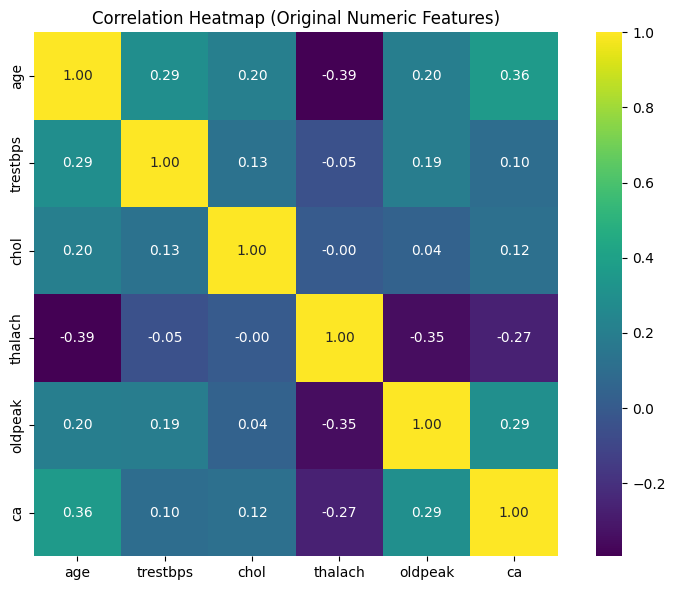

In [33]:
num_features_before_encoding = X.select_dtypes(include=[np.number])
corr = num_features_before_encoding.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", square=True)
plt.title("Correlation Heatmap (Original Numeric Features)")
plt.tight_layout()
plt.show()

### top-3 strongest absolute correlations (excluding diagonal) 

In [34]:
corr_pairs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool)).stack().sort_values(ascending=False)
seen = set() #set so that duplicates donot appear
top3 = []
for (f1, f2), val in corr_pairs.items():
    key = tuple(sorted((f1, f2)))
    if key not in seen:
        seen.add(key)
        top3.append((f1, f2, corr.loc[f1, f2]))
    if len(top3) == 3:
        break

print("Top 3 strongest correlation pairs:")
for i, (f1, f2, v) in enumerate(top3, start=1):
    print(f"{i}. {f1} vs {f2}: {v:.3f}")


Top 3 strongest correlation pairs:
1. thalach vs age: -0.395
2. ca vs age: 0.362
3. thalach vs oldpeak: -0.348


in naive bayes:
Very strong feature correlation can violate the conditional-independence assumption of Naive Bayes,
which may reduce probability calibration and sometimes classification performance.

## Part A: Unsupervised Learning
Unsupervised analysis uses a standardised feature matrix without the target label.

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

### Build feature matrix for unsupervised learning (without target label)

In [47]:
if "heart_clean" not in globals():
    raise ValueError("get heart clean dataet.")

work_df = heart_clean.copy()
if "target" not in work_df.columns:
    work_df["target"] = (work_df["num"] > 0).astype(int)

y_true = work_df["target"].astype(int)

X_raw = work_df.drop(columns=["num", "target"], errors="ignore")

#One-hot encode all categorical/object columns so scaler gets only numeric values
cat_cols_all = X_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
X_encoded = pd.get_dummies(X_raw, columns=cat_cols_all, drop_first=False)

scaler_unsup = StandardScaler()
X_std = scaler_unsup.fit_transform(X_encoded)

print("Categorical columns encoded:", cat_cols_all)
print("Unsupervised matrix shape:", X_std.shape)
print("True label counts:\n", y_true.value_counts().sort_index())

Categorical columns encoded: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Unsupervised matrix shape: (297, 25)
True label counts:
 target
0    160
1    137
Name: count, dtype: int64


# A1

### K-Means Clustering

Run KMeans for k = 2..8, record inertia and silhouette

In [48]:
k_values = list(range(2, 9))
inertias = []
sil_scores = []
models = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_std)
    models[k] = (km, labels)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_std, labels))

# Choose k with highest silhouette score
best_idx = int(np.argmax(sil_scores))
k_best = k_values[best_idx]
km_best, km_labels = models[k_best]


### plot K means

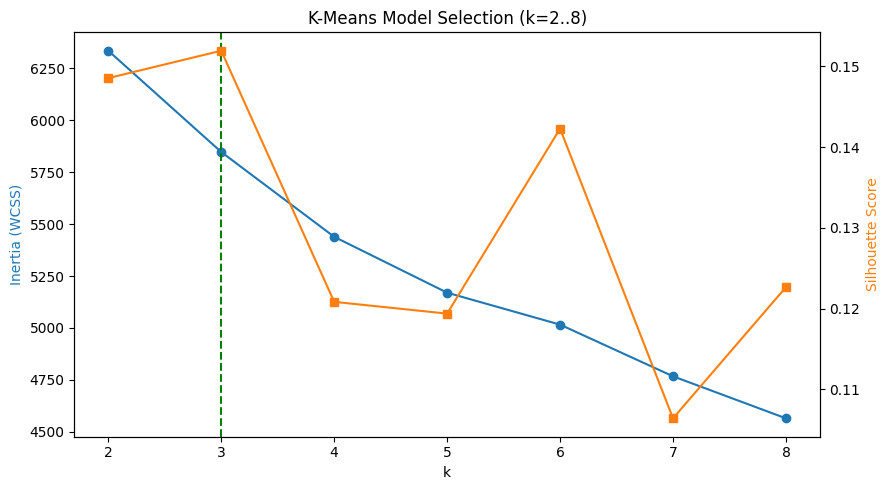

k values: [2, 3, 4, 5, 6, 7, 8]
Inertia: [6334.01, 5846.69, 5438.65, 5169.75, 5016.09, 4767.42, 4565.15]
Silhouette: [0.1486, 0.1519, 0.1208, 0.1194, 0.1423, 0.1064, 0.1227]

Chosen k = 3


In [50]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(k_values, inertias, marker='o', color='tab:blue', label='Inertia (WCSS)')
ax2.plot(k_values, sil_scores, marker='s', color='tab:orange', label='Silhouette')

ax1.axvline(k_best, color='green', linestyle='--', linewidth=1.5)
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia (WCSS)', color='tab:blue')
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax1.set_title('K-Means Model Selection (k=2..8)')

plt.tight_layout()
plt.show()

print('k values:', k_values)
print('Inertia:', [round(v, 2) for v in inertias])
print('Silhouette:', [round(v, 4) for v in sil_scores])
print(f'\nChosen k = {k_best}')

Justification: We choose the k with the best silhouette score while also checking inertia trend.
This gives clusters that are relatively compact and well-separated without over-fragmenting the data.

### PCA 2D scatter: cluster labels vs true labels

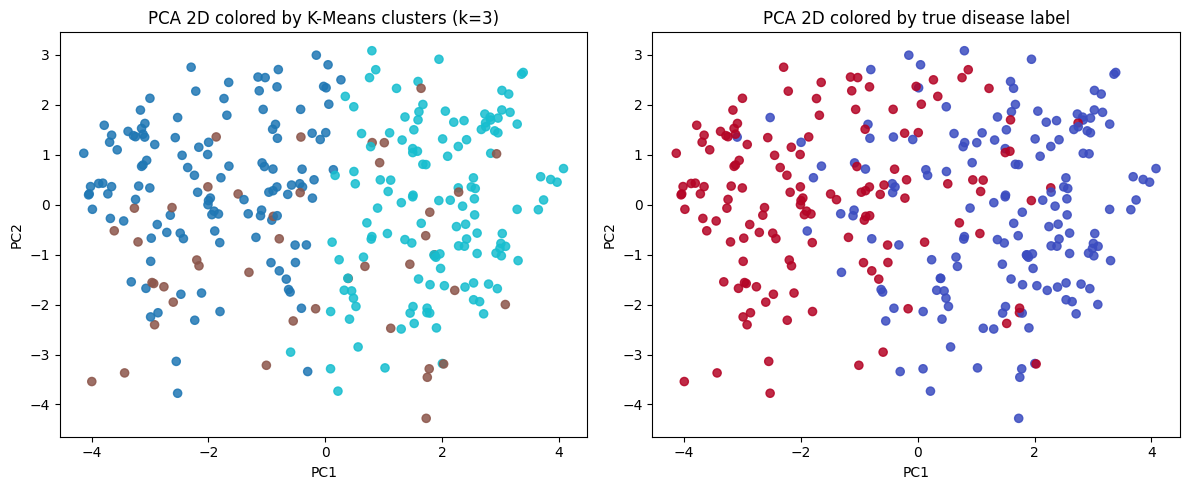

In [52]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=km_labels, cmap='tab10', s=35, alpha=0.85)
axes[0].set_title(f'PCA 2D colored by K-Means clusters (k={k_best})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_true, cmap='coolwarm', s=35, alpha=0.85)
axes[1].set_title('PCA 2D colored by true disease label')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()


### Cluster summary: size, disease proportion, mean thalach/oldpeak/cp

In [55]:
summary_df = work_df.copy()
summary_df['kmeans_cluster'] = km_labels

# cp is categorical, so convert to numeric code for mean reporting
summary_df['cp_code'] = pd.Categorical(summary_df['cp']).codes

cluster_summary = summary_df.groupby('kmeans_cluster').agg(
    cluster_size=('target', 'size'),
    disease_proportion=('target', 'mean'),
    mean_thalach=('thalach', 'mean'),
    mean_oldpeak=('oldpeak', 'mean'),
    mean_cp=('cp_code', 'mean')
).round(3)

print(cluster_summary)

print('\nClinical profile:')
for c in cluster_summary.index:
    r = cluster_summary.loc[c]
    print(
        f"Cluster {c}: n={int(r['cluster_size'])}, disease_prop={r['disease_proportion']:.2f}, "
        f"thalach={r['mean_thalach']:.1f}, oldpeak={r['mean_oldpeak']:.2f}, cp_mean={r['mean_cp']:.2f}."
    )

                cluster_size  disease_proportion  mean_thalach  mean_oldpeak  \
kmeans_cluster                                                                 
0                        122               0.787       137.189         1.618   
1                         43               0.465       149.163         1.079   
2                        132               0.159       161.212         0.528   

                mean_cp  
kmeans_cluster           
0                 0.549  
1                 1.256  
2                 1.235  

Clinical profile:
Cluster 0: n=122, disease_prop=0.79, thalach=137.2, oldpeak=1.62, cp_mean=0.55.
Cluster 1: n=43, disease_prop=0.47, thalach=149.2, oldpeak=1.08, cp_mean=1.26.
Cluster 2: n=132, disease_prop=0.16, thalach=161.2, oldpeak=0.53, cp_mean=1.24.


### ARI between K-Means clusters and true labels

In [54]:
ari_kmeans_true = adjusted_rand_score(y_true, km_labels)
print(f'Adjusted Rand Index (K-Means vs true labels): {ari_kmeans_true:.4f}')

Adjusted Rand Index (K-Means vs true labels): 0.2870


Interpretation: ARI near 0 means little agreement beyond chance; closer to 1 means strong natural grouping by disease label.

# A2

### Hierarchical Clustering

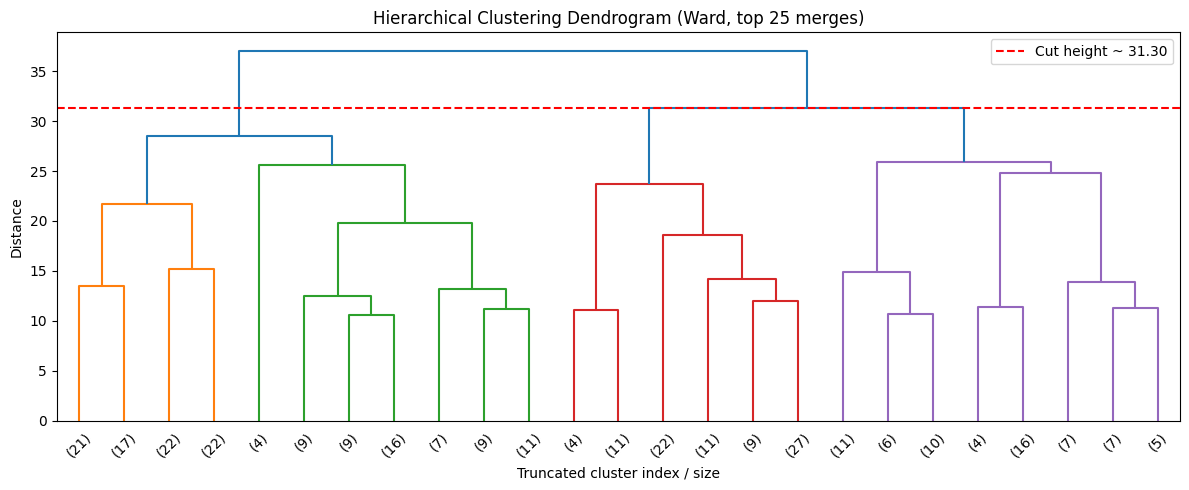

Recommended cut: around 31.30, giving 3 clusters.


In [56]:
# Ward linkage + dendrogram 
Z = linkage(X_std, method='ward')

# Use same number of clusters as chosen in K-Means for fair comparison
n_clusters_h = k_best

# Approximate cut height for annotation
cut_height = Z[-(n_clusters_h - 1), 2] if n_clusters_h > 1 else Z[-1, 2]

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=25, show_leaf_counts=True)
plt.axhline(y=cut_height, color='red', linestyle='--', label=f'Cut height ~ {cut_height:.2f}')
plt.title('Hierarchical Clustering Dendrogram (Ward, top 25 merges)')
plt.xlabel('Truncated cluster index / size')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Recommended cut: around {cut_height:.2f}, giving {n_clusters_h} clusters.')

### Cut tree and compare clusters with true labels

In [57]:
hier = AgglomerativeClustering(n_clusters=n_clusters_h, linkage='ward')
hier_labels = hier.fit_predict(X_std)

ct = pd.crosstab(
    pd.Series(hier_labels, name='hier_cluster'),
    pd.Series(y_true.values, name='true_label')
)
print('Cluster vs true label crosstab:')
print(ct)

Cluster vs true label crosstab:
true_label      0   1
hier_cluster         
0             106  41
1              39  27
2              15  69


### ARI between hierarchical and K-Means assignments

In [58]:
ari_kmeans_hier = adjusted_rand_score(km_labels, hier_labels)
print(f'ARI (Hierarchical vs K-Means): {ari_kmeans_hier:.4f}')

ARI (Hierarchical vs K-Means): 0.4268


If ARI is high, both methods discover a similar segmentation pattern in the data.
K-Means is usually easier to interpret with stable centroids, while hierarchical clustering shows nested relationships.
For clinical segmentation, trust the method that gives more stable groups and clearer clinical summaries across reruns.

# A3

### dimensionality reduction

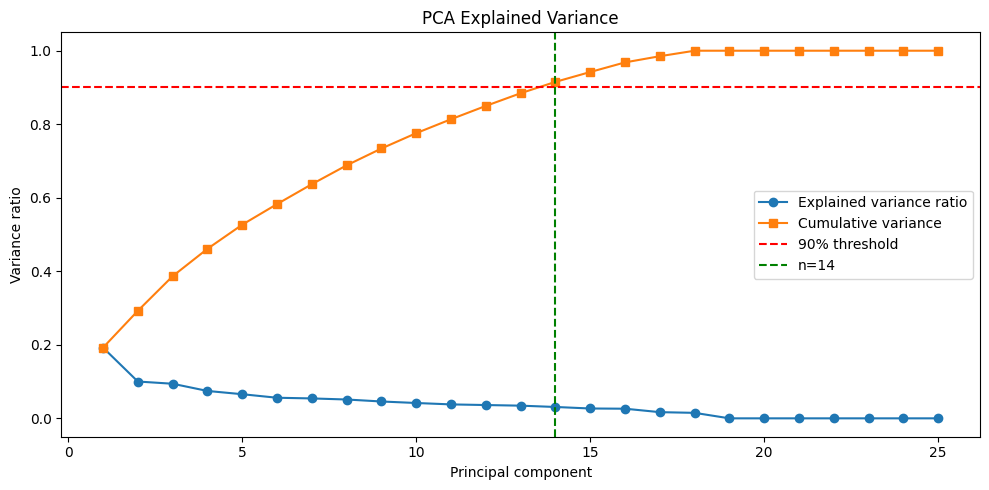

Number of components needed for 90% variance: 14


In [60]:
#pca
pca_full = PCA(random_state=42)
pca_full.fit(X_std)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

n90 = int(np.argmax(cum_evr >= 0.90) + 1)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(range(1, len(evr) + 1), evr, marker='o', label='Explained variance ratio')
ax1.plot(range(1, len(cum_evr) + 1), cum_evr, marker='s', label='Cumulative variance')
ax1.axhline(0.90, color='red', linestyle='--', label='90% threshold')
ax1.axvline(n90, color='green', linestyle='--', label=f'n={n90}')
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Variance ratio')
ax1.set_title('PCA Explained Variance')
ax1.legend()
plt.tight_layout()
plt.show()

print(f'Number of components needed for 90% variance: {n90}')

### T-sne plot

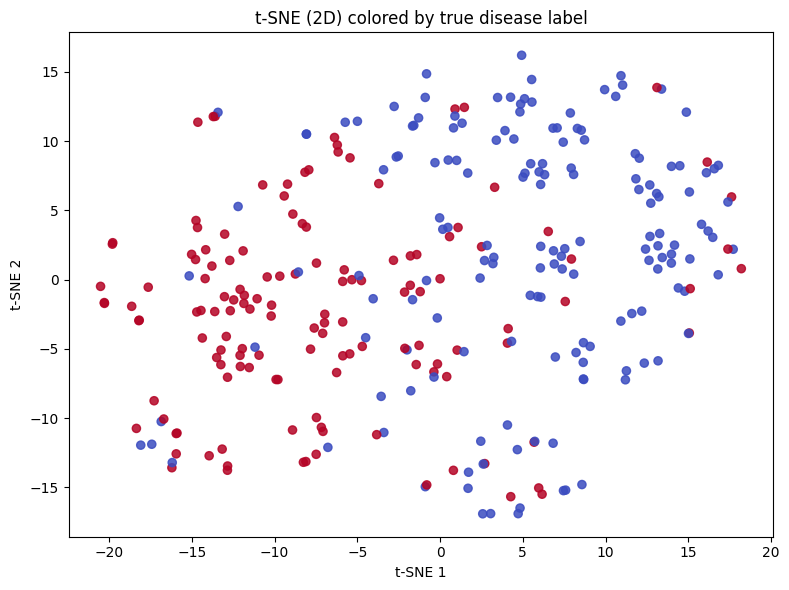

In [62]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_std)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='coolwarm', s=35, alpha=0.85)
plt.title('t-SNE (2D) colored by true disease label')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()


features overlap mostly, the boundary is complex, so classification is harder and may need stronger models/features

## Part B: Bagging & Boosting

In [97]:
import time
import sys
import subprocess

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Ensure xgboost and shap are available
for pkg in ["xgboost", "shap"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

from xgboost import XGBClassifier
import shap

### evaluate classifier 

In [98]:
required_vars = ["X_train", "X_test", "y_train", "y_test", "preprocessor"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Missing variables: {missing}")


def evaluate_classifier(model, X_te, y_te, name="Model"):
    y_pred = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        # fallback for models without predict_proba
        y_prob = y_pred.astype(float)

    metrics = {
        "Classifier": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Macro Precision": precision_score(y_te, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_te, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_te, y_pred, average="macro", zero_division=0),
        "AUC-ROC": roc_auc_score(y_te, y_prob),
        "Recall (Disease)": recall_score(y_te, y_pred, pos_label=1, zero_division=0),
    }

    print(f"\n{name} Metrics")
    for k, v in metrics.items():
        if k != "Classifier":
            print(f"{k}: {v:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    return metrics, y_prob

# B1

### Random Forest (Bagging)

###  RF tuning with 5-fold CV on training set

In [ ]:
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True, bootstrap=True))
])

rf_grid = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [None, 5, 10]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

start_rf = time.time()
rf_search = GridSearchCV(
    rf_pipe,
    param_grid=rf_grid,
    scoring="f1_macro",
    cv=cv5,
    n_jobs=-1,
    refit=True
)
rf_search.fit(X_train, y_train)
rf_train_time = time.time() - start_rf

best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)
print(f"Best mean CV Macro-F1: {rf_search.best_score_:.4f}")
print(f"RF train+tuning time (s): {rf_train_time:.2f}")

Best RF params: {'rf__max_depth': 5, 'rf__n_estimators': 50}
Best mean CV Macro-F1: 0.8137
RF train+tuning time (s): 8.00


### preprocessing for Part B models (encode all categorical columns)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols_b = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols_b = [c for c in X_train.columns if c not in cat_cols_b]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_b),
        ("num", StandardScaler(), num_cols_b),
    ],
    remainder="drop"
)

print("Updated Part B preprocessor")
print("Categorical:", cat_cols_b)
print("Numeric:", num_cols_b)

Updated Part B preprocessor
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']


### Plot the Out-Of-Bag (OOB) error vs number of trees for n_estimators

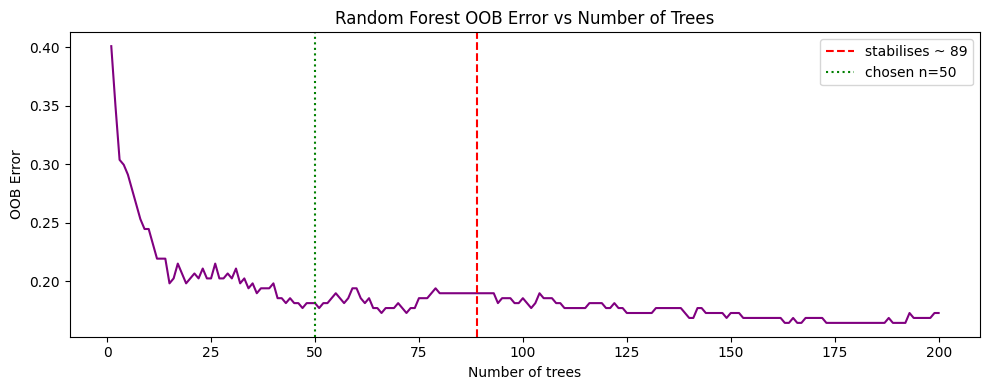

OOB error stabilises around: 89 trees
Chosen n_estimators: 50


In [ ]:
X_train_prep = preprocessor.fit_transform(X_train)

oob_errors = []
for n in range(1, 201):
    rf_oob = RandomForestClassifier(
        n_estimators=n,
        max_depth=rf_search.best_params_["rf__max_depth"],
        random_state=42,
        n_jobs=-1,
        oob_score=True,
        bootstrap=True
    )
    rf_oob.fit(X_train_prep, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

# first index where improvement in last 10 trees is tiny
stabilize_n = 200
for n in range(20, 201):
    recent = oob_errors[n-10:n]
    if max(recent) - min(recent) < 0.002:
        stabilize_n = n
        break

plt.figure(figsize=(10, 4))
plt.plot(range(1, 201), oob_errors, color="purple")
plt.axvline(stabilize_n, color="red", linestyle="--", label=f"stabilises ~ {stabilize_n}")
plt.axvline(rf_search.best_params_["rf__n_estimators"], color="green", linestyle=":", label=f"chosen n={rf_search.best_params_['rf__n_estimators']}")
plt.xlabel("Number of trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error vs Number of Trees")
plt.legend()
plt.tight_layout()
plt.show()

print(f"OOB error stabilises around: {stabilize_n} trees")
print(f"Chosen n_estimators: {rf_search.best_params_['rf__n_estimators']}")

### Feature importance plot 

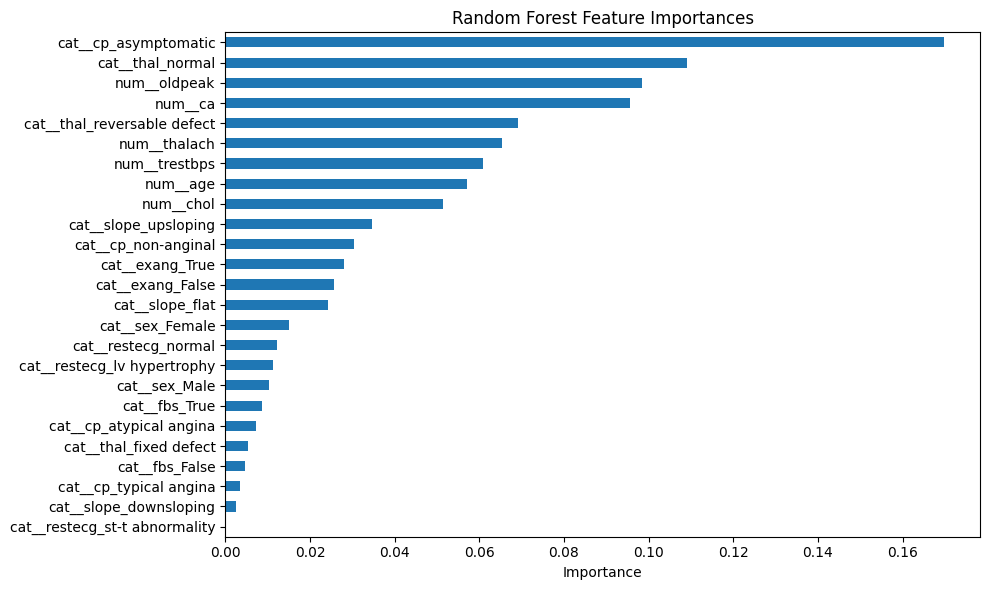

Top 5 features:
cat__cp_asymptomatic           0.169784
cat__thal_normal               0.108983
num__oldpeak                   0.098362
num__ca                        0.095629
cat__thal_reversable defect    0.069160
dtype: float64


In [99]:
rf_model = best_rf.named_steps["rf"]
prep_model = best_rf.named_steps["prep"]
feature_names = prep_model.get_feature_names_out()

fi = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, max(6, len(fi) * 0.22)))
fi.plot(kind="barh")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

top5 = fi.sort_values(ascending=False).head(5)
print("Top 5 features:")
print(top5)

Clinical plausibility 
- cat__cp_asymptomatic: Number of major vessels affected is directly related to extent of arterial blockage.
- cat__thal_normal: Number of major vessels affected is directly related to extent of arterial blockage.
- num__oldpeak: ST depression reflects ischemic changes linked to coronary artery disease severity.
- num__ca: Number of major vessels affected is directly related to extent of arterial blockage.
- cat__thal_reversable defect: Number of major vessels affected is directly related to extent of arterial blockage

### RF final evaluation


Random Forest Metrics
Accuracy: 0.7833
Macro Precision: 0.7914
Macro Recall: 0.7768
Macro F1: 0.7783
AUC-ROC: 0.9297
Recall (Disease): 0.6786


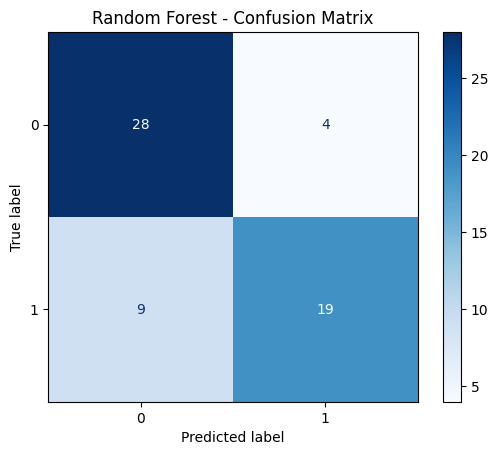

In [ ]:
rf_metrics, rf_prob = evaluate_classifier(best_rf, X_test, y_test, name="Random Forest")

Class with lower recall is the one we miss more often.
If disease-present recall is lower, false negatives mean patients with disease may be missed and not referred for timely care.

# B2

### Gradient Boosting (XGBoost)

In [101]:
# XGBoost tuning with 5-fold CV on training set
print("Model choice: XGBoost")

xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("xgb", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_estimators=300,
        objective="binary:logistic"
    ))
])

xgb_grid = {
    "xgb__learning_rate": [0.01, 0.1, 0.3],
    "xgb__max_depth": [3, 5, 7]
}

start_xgb = time.time()
xgb_search = GridSearchCV(
    xgb_pipe,
    param_grid=xgb_grid,
    scoring="f1_macro",
    cv=cv5,
    n_jobs=-1,
    refit=True
)
xgb_search.fit(X_train, y_train)
xgb_train_time = time.time() - start_xgb

best_xgb_pipe = xgb_search.best_estimator_
print("Best XGBoost params:", xgb_search.best_params_)
print(f"Best mean CV Macro-F1: {xgb_search.best_score_:.4f}")
print(f"XGBoost train+tuning time (s): {xgb_train_time:.2f}")

Model choice: XGBoost
Best XGBoost params: {'xgb__learning_rate': 0.3, 'xgb__max_depth': 3}
Best mean CV Macro-F1: 0.7988
XGBoost train+tuning time (s): 14.18


###  Train final XGBoost with early stopping (patience 50)

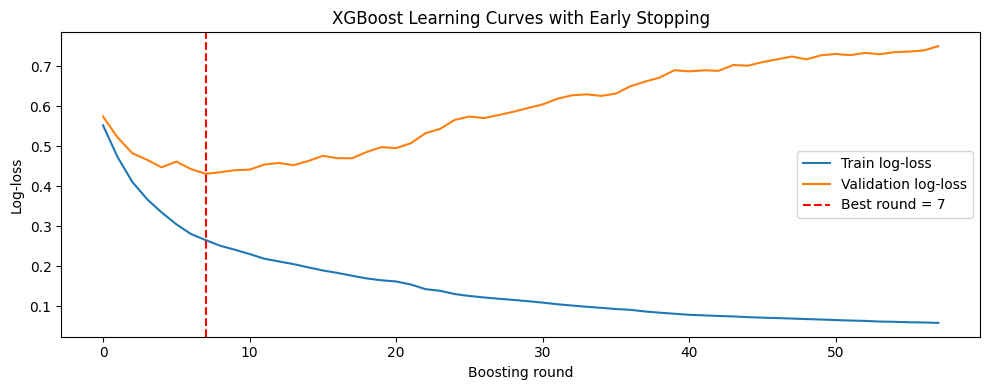

Best boosting round: 7


In [103]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

prep_es = preprocessor
X_tr_p = prep_es.fit_transform(X_tr)
X_val_p = prep_es.transform(X_val)
X_test_p = prep_es.transform(X_test)

# convert sparse to dense if needed for compatibility
if hasattr(X_tr_p, "toarray"):
    X_tr_p = X_tr_p.toarray()
    X_val_p = X_val_p.toarray()
    X_test_p = X_test_p.toarray()

final_xgb = XGBClassifier(
    random_state=42,
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=2000,
    learning_rate=xgb_search.best_params_["xgb__learning_rate"],
    max_depth=xgb_search.best_params_["xgb__max_depth"],
    early_stopping_rounds=50
)

final_xgb.fit(
    X_tr_p, y_tr,
    eval_set=[(X_tr_p, y_tr), (X_val_p, y_val)],
    verbose=False
)

evals = final_xgb.evals_result()
train_logloss = evals["validation_0"]["logloss"]
val_logloss = evals["validation_1"]["logloss"]
best_round = int(final_xgb.best_iteration)

plt.figure(figsize=(10, 4))
plt.plot(train_logloss, label="Train log-loss")
plt.plot(val_logloss, label="Validation log-loss")
plt.axvline(best_round, color="red", linestyle="--", label=f"Best round = {best_round}")
plt.xlabel("Boosting round")
plt.ylabel("Log-loss")
plt.title("XGBoost Learning Curves with Early Stopping")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best boosting round: {best_round}")

as validation log-loss rises while training log-loss keeps falling, overfitting is present

### SHAP values for the test set

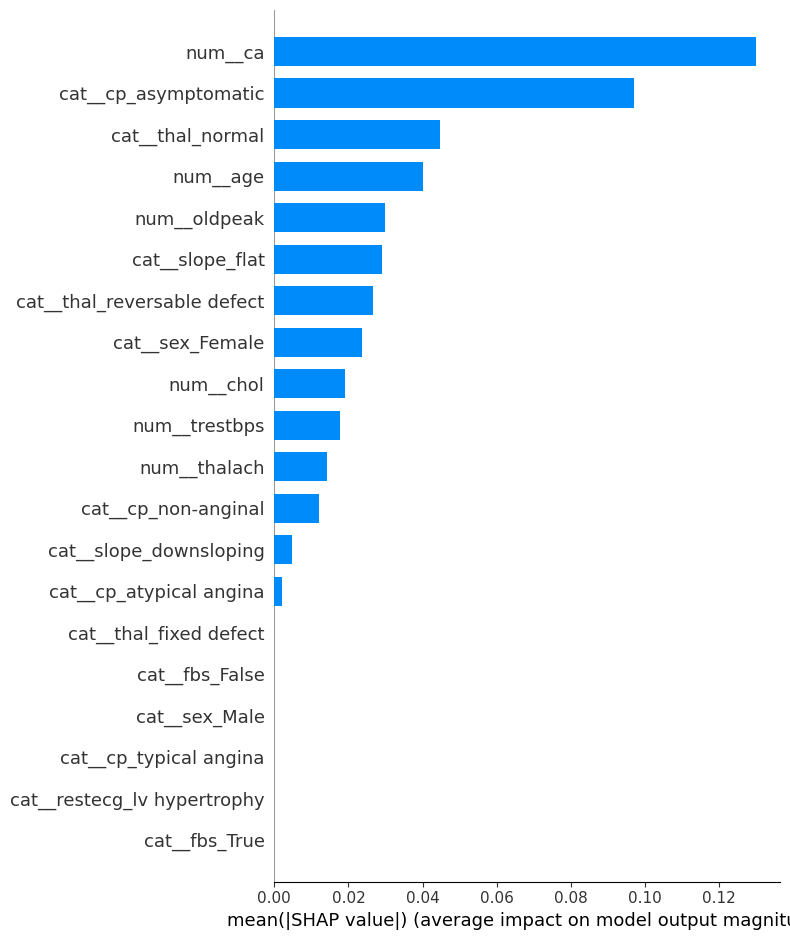

Top SHAP features (mean |SHAP|):
num__ca                        0.130014
cat__cp_asymptomatic           0.097088
cat__thal_normal               0.044606
num__age                       0.040092
num__oldpeak                   0.030008
cat__slope_flat                0.029099
cat__thal_reversable defect    0.026516
cat__sex_Female                0.023791
num__chol                      0.019195
num__trestbps                  0.017732
dtype: float64


In [ ]:
# Use callable model + small background set for broad SHAP version compatibility
bg_size = min(50, len(X_test_p))
X_bg = X_test_p[:bg_size]

explainer = shap.Explainer(lambda z: final_xgb.predict_proba(z)[:, 1], X_bg)
shap_exp = explainer(X_test_p)
shap_values = shap_exp.values

# summary bar plot (simple and readable)
shap.summary_plot(shap_values, X_test_p, feature_names=prep_es.get_feature_names_out(), plot_type="bar")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_top = pd.Series(mean_abs_shap, index=prep_es.get_feature_names_out()).sort_values(ascending=False).head(10)
print("Top SHAP features (mean |SHAP|):")
print(shap_top)

###  XGBoost final evaluation on test set


XGBoost Metrics
Accuracy: 0.8167
Macro Precision: 0.8267
Macro Recall: 0.8103
Macro F1: 0.8124
AUC-ROC: 0.9364
Recall (Disease): 0.7143


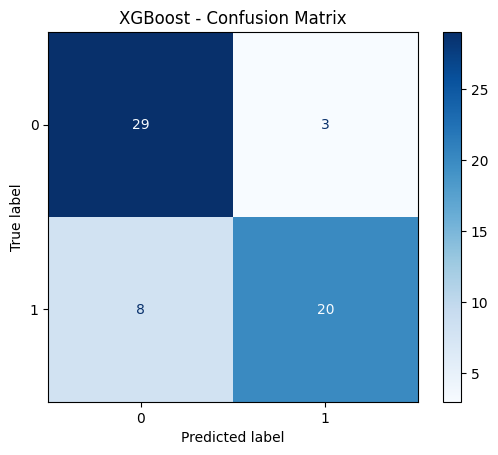

In [ ]:
xgb_pred = final_xgb.predict(X_test_p)
xgb_prob = final_xgb.predict_proba(X_test_p)[:, 1]

xgb_metrics = {
    "Classifier": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Macro Precision": precision_score(y_test, xgb_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, xgb_pred, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, xgb_pred, average="macro", zero_division=0),
    "AUC-ROC": roc_auc_score(y_test, xgb_prob),
    "Recall (Disease)": recall_score(y_test, xgb_pred, pos_label=1, zero_division=0),
}

print("\nXGBoost Metrics")
for k, v in xgb_metrics.items():
    if k != "Classifier":
        print(f"{k}: {v:.4f}")

cm_xgb = confusion_matrix(y_test, xgb_pred)
ConfusionMatrixDisplay(cm_xgb, display_labels=[0, 1]).plot(cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.show()